# Mental Health in the Workplace — EDA
**Dataset:** OSMI Mental Health in Tech Survey (1,259 respondents)  
**Tools:** Python · Pandas · Seaborn · Matplotlib  
**Goal:** Identify attrition risk factors, employer support gaps, and intervention opportunities

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────
DARK_BG    = '#1C1C1C'
CARD_BG    = '#252525'
ORANGE     = '#E8653A'
BLUE       = '#4472C4'
PURPLE     = '#7B3FA0'
WHITE      = '#F0F0F0'
MUTED      = '#888888'
PALETTE    = [ORANGE, BLUE, PURPLE, '#27AE60', '#E74C3C']

plt.rcParams.update({
    'figure.facecolor'  : DARK_BG,
    'axes.facecolor'    : CARD_BG,
    'axes.edgecolor'    : '#3A3A3A',
    'axes.labelcolor'   : WHITE,
    'axes.titlecolor'   : WHITE,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.grid'         : True,
    'grid.color'        : '#333333',
    'grid.linewidth'    : 0.5,
    'xtick.color'       : MUTED,
    'ytick.color'       : MUTED,
    'text.color'        : WHITE,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'savefig.facecolor' : DARK_BG,
    'savefig.dpi'       : 150,
    'savefig.bbox'      : 'tight'
})

df = pd.read_csv('../data/mental_health_clean.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Dataset loaded: 1259 rows × 33 columns


,Age,Gender,Country,SelfEmployed,FamilyHistory,Treatment,WorkInterfere,CompanySize,RemoteWork,TechCompany,...,ObservedConsequence,AgeBand,treatment_binary,remote_work_binary,family_history_binary,work_interfere_score,employer_support_score,employer_support_label,high_risk,company_size_order
0,37,Female,United States,No,No,Yes,Often,6-25,No,Yes,...,No,36-45,1,0,0,3,2,Medium,0,2
1,44,Male,United States,No,No,No,Rarely,More than 1000,No,No,...,No,36-45,0,0,0,1,0,No Support,0,6
2,32,Male,Canada,No,No,No,Rarely,6-25,No,Yes,...,No,26-35,0,0,0,1,0,No Support,0,2


## 2. Key Metrics Summary

In [2]:
total          = len(df)
treatment_rate = df['treatment_binary'].mean() * 100
high_risk      = df['high_risk'].sum()
remote_workers = df['remote_work_binary'].sum()
no_support     = (df['employer_support_score'] == 0).sum()
often_interfere= (df['WorkInterfere'] == 'Often').sum()

print('=' * 45)
print('  MENTAL HEALTH IN TECH — KEY METRICS')
print('=' * 45)
print(f'  Total Respondents       : {total:,}')
print(f'  Sought Treatment        : {treatment_rate:.1f}%')
print(f'  High Risk Employees     : {high_risk}')
print(f'  Work Often Interferes   : {often_interfere}')
print(f'  Zero Employer Support   : {no_support}')
print(f'  Remote Workers          : {remote_workers}')
print('=' * 45)

  MENTAL HEALTH IN TECH — KEY METRICS
  Total Respondents       : 1,259
  Sought Treatment        : 50.6%
  High Risk Employees     : 92
  Work Often Interferes   : 144
  Zero Employer Support   : 714
  Remote Workers          : 376


## Chart 1 — Treatment Rate by Top 10 Countries

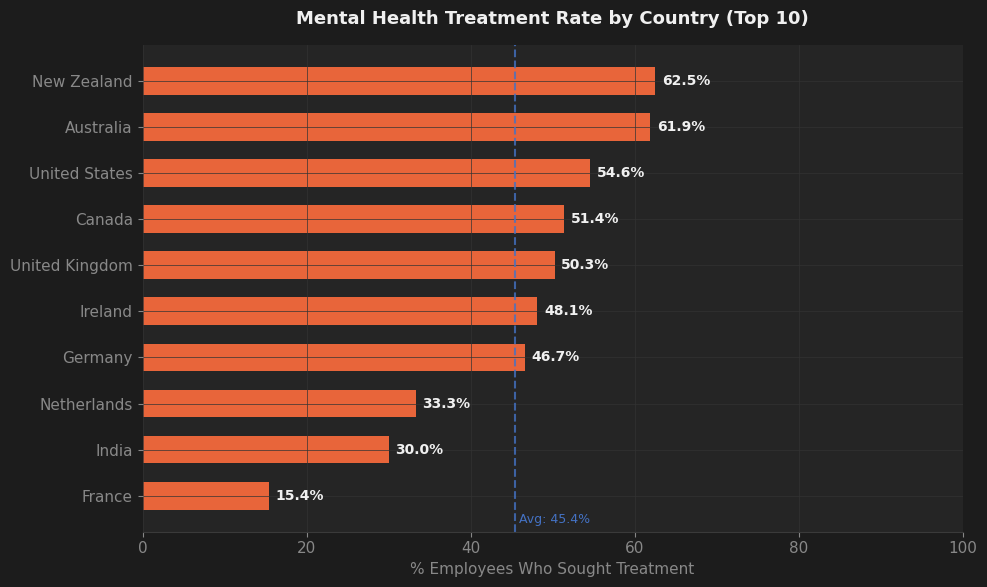

Saved: visuals/chart1_treatment_by_country.png


In [3]:
# Filter top 10 countries by respondent count
top_countries = df['Country'].value_counts().head(10).index
country_df = df[df['Country'].isin(top_countries)].copy()

country_stats = (country_df.groupby('Country')['treatment_binary']
                 .agg(['mean', 'count'])
                 .reset_index()
                 .rename(columns={'mean': 'TreatmentRate', 'count': 'Count'}))
country_stats['TreatmentRate'] *= 100
country_stats = country_stats.sort_values('TreatmentRate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(country_stats['Country'], country_stats['TreatmentRate'],
               color=ORANGE, edgecolor='none', height=0.6)

# Add value labels
for bar, val in zip(bars, country_stats['TreatmentRate']):
    ax.text(val + 0.8, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            color=WHITE, fontsize=10, fontweight='bold')

# Average line
avg = country_stats['TreatmentRate'].mean()
ax.axvline(avg, color=BLUE, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(avg + 0.5, -0.6, f'Avg: {avg:.1f}%', color=BLUE, fontsize=9)

ax.set_xlabel('% Employees Who Sought Treatment', color=MUTED)
ax.set_title('Mental Health Treatment Rate by Country (Top 10)', pad=15)
ax.set_xlim(0, 100)
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/chart1_treatment_by_country.png')
plt.show()
print('Saved: visuals/chart1_treatment_by_country.png')

## Chart 2 — Work Interference vs Treatment (Heatmap)

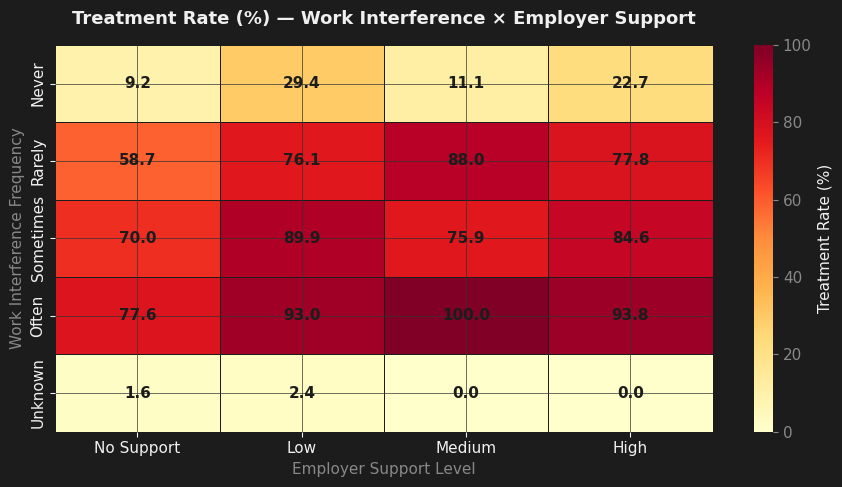

Saved: visuals/chart2_interference_support_heatmap.png


In [4]:
# Cross-tab: WorkInterfere × employer_support_label, colored by treatment rate
order_interfere = ['Never', 'Rarely', 'Sometimes', 'Often', 'Unknown']
order_support   = ['No Support', 'Low', 'Medium', 'High']

heat_df = (df[df['WorkInterfere'].isin(order_interfere)]
           .groupby(['WorkInterfere', 'employer_support_label'])['treatment_binary']
           .mean() * 100).unstack()

heat_df = heat_df.reindex(index=order_interfere, columns=order_support)

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#1C1C1C',
            annot_kws={'size': 11, 'weight': 'bold', 'color': '#1C1C1C'},
            ax=ax, cbar_kws={'label': 'Treatment Rate (%)'})

ax.set_title('Treatment Rate (%) — Work Interference × Employer Support', pad=15)
ax.set_xlabel('Employer Support Level', color=MUTED)
ax.set_ylabel('Work Interference Frequency', color=MUTED)
ax.tick_params(colors=WHITE)

plt.tight_layout()
plt.savefig('../visuals/chart2_interference_support_heatmap.png')
plt.show()
print('Saved: visuals/chart2_interference_support_heatmap.png')

## Chart 3 — Remote Work vs Mental Health Impact

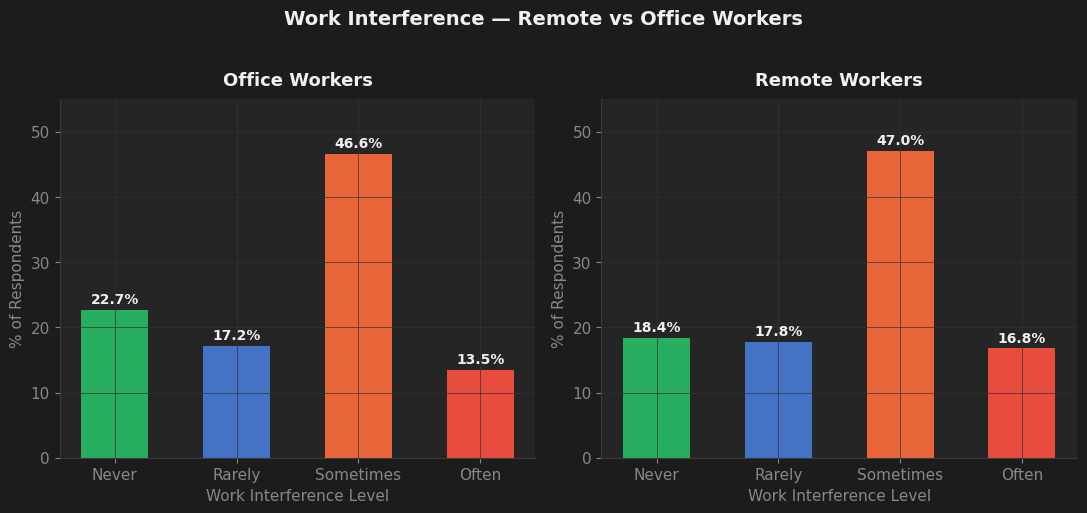

Saved: visuals/chart3_remote_vs_interference.png


In [5]:
remote_df = (df[df['WorkInterfere'] != 'Unknown']
             .groupby(['RemoteWork', 'WorkInterfere'])
             .size().reset_index(name='Count'))

# Calculate percentages within each remote group
totals = remote_df.groupby('RemoteWork')['Count'].transform('sum')
remote_df['Pct'] = remote_df['Count'] / totals * 100

interfere_order = ['Never', 'Rarely', 'Sometimes', 'Often']
remote_df = remote_df[remote_df['WorkInterfere'].isin(interfere_order)]
colors_map = {'Never': '#27AE60', 'Rarely': BLUE,
              'Sometimes': ORANGE, 'Often': '#E74C3C'}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)

for i, remote_val in enumerate(['No', 'Yes']):
    sub = remote_df[remote_df['RemoteWork'] == remote_val]
    sub = sub.set_index('WorkInterfere').reindex(interfere_order).reset_index()
    ax = axes[i]
    bars = ax.bar(sub['WorkInterfere'], sub['Pct'],
                  color=[colors_map[w] for w in sub['WorkInterfere']],
                  edgecolor='none', width=0.55)
    for bar, val in zip(bars, sub['Pct']):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom',
                    color=WHITE, fontsize=10, fontweight='bold')
    label = 'Office Workers' if remote_val == 'No' else 'Remote Workers'
    ax.set_title(label, pad=10)
    ax.set_xlabel('Work Interference Level', color=MUTED)
    ax.set_ylabel('% of Respondents', color=MUTED)
    ax.set_ylim(0, 55)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Work Interference — Remote vs Office Workers', fontsize=14,
             fontweight='bold', color=WHITE, y=1.02)
plt.tight_layout()
plt.savefig('../visuals/chart3_remote_vs_interference.png')
plt.show()
print('Saved: visuals/chart3_remote_vs_interference.png')

## Chart 4 — Age Distribution of High Interference Employees

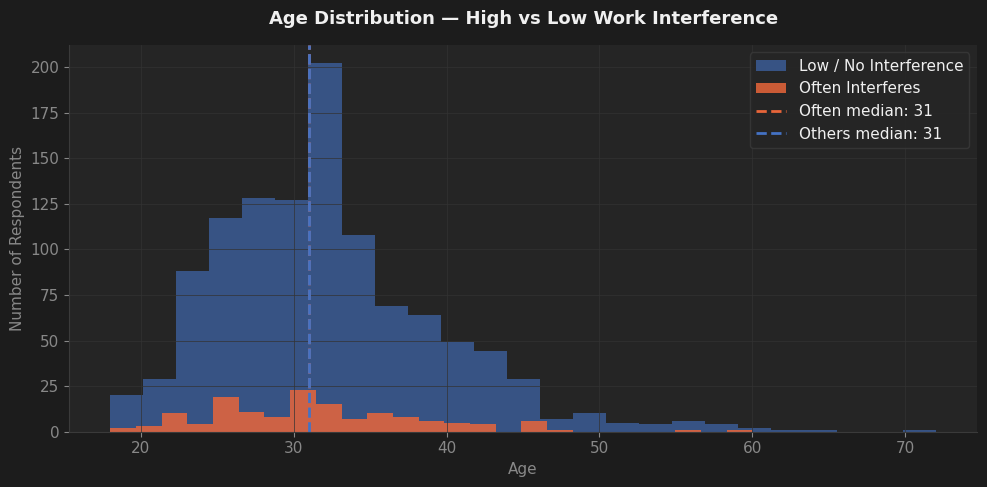

Saved: visuals/chart4_age_distribution.png


In [6]:
often_df    = df[df['WorkInterfere'] == 'Often']['Age']
not_often_df= df[df['WorkInterfere'] != 'Often']['Age']

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(not_often_df, bins=25, color=BLUE, alpha=0.6,
        label='Low / No Interference', edgecolor='none')
ax.hist(often_df, bins=25, color=ORANGE, alpha=0.85,
        label='Often Interferes', edgecolor='none')

# Median lines
ax.axvline(often_df.median(), color=ORANGE, linewidth=2,
           linestyle='--', label=f'Often median: {often_df.median():.0f}')
ax.axvline(not_often_df.median(), color=BLUE, linewidth=2,
           linestyle='--', label=f'Others median: {not_often_df.median():.0f}')

ax.set_title('Age Distribution — High vs Low Work Interference', pad=15)
ax.set_xlabel('Age', color=MUTED)
ax.set_ylabel('Number of Respondents', color=MUTED)
ax.legend(facecolor=CARD_BG, edgecolor='#3A3A3A', labelcolor=WHITE)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/chart4_age_distribution.png')
plt.show()
print('Saved: visuals/chart4_age_distribution.png')

## Chart 5 — Correlation Matrix (Numeric Columns)

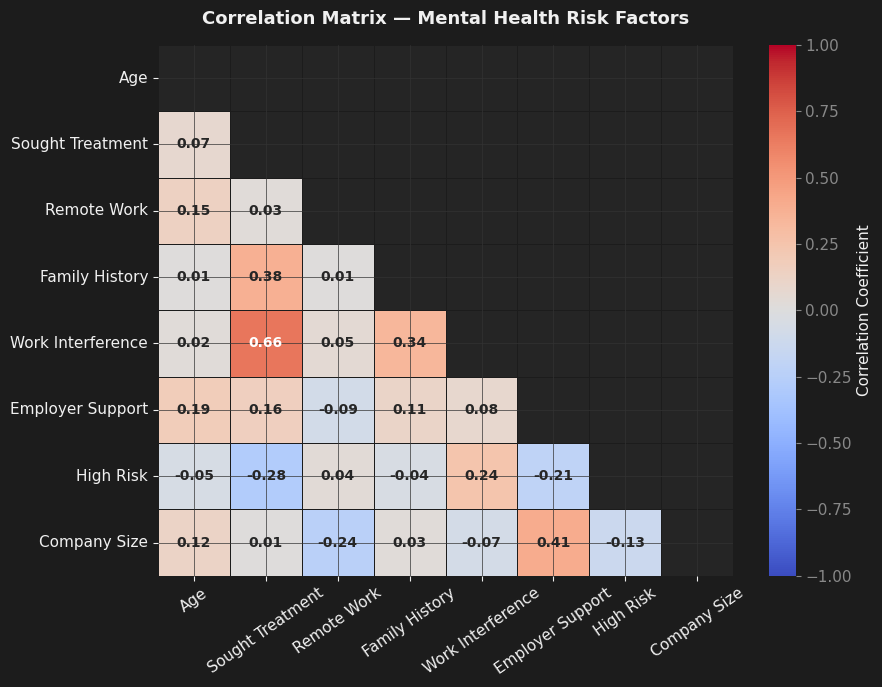

Saved: visuals/chart5_correlation_matrix.png


In [7]:
numeric_cols = [
    'Age', 'treatment_binary', 'remote_work_binary',
    'family_history_binary', 'work_interfere_score',
    'employer_support_score', 'high_risk', 'company_size_order'
]

readable_labels = [
    'Age', 'Sought Treatment', 'Remote Work',
    'Family History', 'Work Interference',
    'Employer Support', 'High Risk', 'Company Size'
]

corr_df = df[numeric_cols].dropna().corr()
corr_df.columns = readable_labels
corr_df.index   = readable_labels

mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#1C1C1C',
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax, cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Correlation Matrix — Mental Health Risk Factors', pad=15)
ax.tick_params(axis='x', rotation=35, colors=WHITE)
ax.tick_params(axis='y', rotation=0,  colors=WHITE)

plt.tight_layout()
plt.savefig('../visuals/chart5_correlation_matrix.png')
plt.show()
print('Saved: visuals/chart5_correlation_matrix.png')

## Summary of Key Findings

In [8]:
often_treatment = df[df['WorkInterfere']=='Often']['treatment_binary'].mean()*100
never_treatment = df[df['WorkInterfere']=='Never']['treatment_binary'].mean()*100
no_support_risk = df[df['employer_support_score']==0]['high_risk'].mean()*100
high_support_risk= df[df['employer_support_score']==3]['high_risk'].mean()*100
family_hist_rate = df[df['family_history_binary']==1]['treatment_binary'].mean()*100

print('=' * 50)
print('  KEY FINDINGS')
print('=' * 50)
print(f'  Treatment rate — Often interfered : {often_treatment:.1f}%')
print(f'  Treatment rate — Never interfered : {never_treatment:.1f}%')
print(f'  High risk — Zero employer support : {no_support_risk:.1f}%')
print(f'  High risk — Full employer support : {high_support_risk:.1f}%')
print(f'  Family history → treatment rate   : {family_hist_rate:.1f}%')
print(f'  Total high risk employees         : {df["high_risk"].sum()}')
print('=' * 50)

  KEY FINDINGS
  Treatment rate — Often interfered : 85.4%
  Treatment rate — Never interfered : 14.1%
  High risk — Zero employer support : 12.9%
  High risk — Full employer support : 0.0%
  Family history → treatment rate   : 74.2%
  Total high risk employees         : 92
